# Counts Analysis

Notebook para carregar os arquivos processados de `published_counts`, plotar as series log-log e ajustar os coeficientes `d_f`, `d_min`, `d_hull` e `d_hull_ext`.

In [18]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd() / "src"))

from src.CountsAnalysis import (
    OBSERVABLES,
    processed_counts_index,
    filter_index,
    read_counts_file,
    fit_samples,
    fit_all_observables,
    summarize_fits,
    plot_sample,
    plot_mean,
    rounded_value_error,
    
)

plt.style.use("properties.mplstyle") if Path("properties.mplstyle").exists() else None

## Datasets Processados

In [19]:
df_index = processed_counts_index("../SOP_data/published_counts")
df_index

,type_percolation,num_colors,dim,L,f_T,c,rho,gap_over_L,P0,p0,path,n_count_files,n_samples,n_legacy_d_min_fallback_samples,n_d_min_yardstick_samples,last_run_new_samples,last_run_updated_samples,raw_count_files_this_run,existing_processed_files
0,bond,1,2,16384,0.068737,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,16,72,0,72,0,0,0,1
1,bond,1,2,16384,0.072174,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,3,20,0,20,0,0,0,1
2,bond,1,2,16384,0.103106,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,5,50,0,49,0,0,0,1
3,bond,1,2,16384,0.137474,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,5,50,0,50,0,0,0,1
4,bond,1,2,16384,0.206212,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,5,50,0,50,0,0,0,1
5,node,1,2,16384,0.075679,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,10,93,0,93,93,0,10,0
6,node,1,2,16384,0.076493,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,10,84,0,84,84,0,10,0
7,node,1,2,16384,0.077306,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,9,75,0,75,75,0,9,0
8,node,1,2,16384,0.078120,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,9,81,0,81,81,0,9,0
9,node,1,2,16384,0.078934,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,10,100,0,100,100,0,10,0


## Escolha Do Conjunto

In [33]:
selection = filter_index(
    df_index,
    type_percolation="bond",
    dim=2,
    L=16384,
    c=0.01,
    rho=1.0,
    P0=0.2,
    p0=0.8,
)

selection

,type_percolation,num_colors,dim,L,f_T,c,rho,gap_over_L,P0,p0,path,n_count_files,n_samples,n_legacy_d_min_fallback_samples,n_d_min_yardstick_samples,last_run_new_samples,last_run_updated_samples,raw_count_files_this_run,existing_processed_files
0,bond,1,2,16384,0.068737,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,16,72,0,72,0,0,0,1
1,bond,1,2,16384,0.072174,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,3,20,0,20,0,0,0,1
2,bond,1,2,16384,0.103106,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,5,50,0,49,0,0,0,1
3,bond,1,2,16384,0.137474,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,5,50,0,50,0,0,0,1
4,bond,1,2,16384,0.206212,0.01,1.0,1.5,0.2,0.8,/home/light/Documents/self_organization_percol...,5,50,0,50,0,0,0,1


In [35]:
dataset_path = Path(selection.iloc[0]["path"])
payload = read_counts_file(dataset_path)

dataset_path, payload["meta"]

(PosixPath('/home/light/Documents/self_organization_percolation/SOP_data/published_counts/bond_percolation/dim_2/L_16384/fT_0.06873726/c_0.01/rho_1/counts_P0_0.2_p0_0.8.json'),
 {'type_percolation': 'bond',
  'num_colors': 1,
  'dim': 2,
  'L': 16384,
  'f_T': 0.06873726,
  'c': 0.01,
  'rho': 1.0,
  'gap_over_L': 1.5,
  'P0': 0.2,
  'p0': 0.8,
  'relations': {'d_f': 'N_bulk ~ (L_over_epsilon)^d_f',
   'd_hull': 'N_hull ~ (L_over_epsilon)^d_hull',
   'd_hull_ext': 'N_hull_ext ~ (L_over_epsilon)^d_hull_ext',
   'd_min': 'ell ~ r^d_min',
   'd_min_yardstick': 'N_R ~ (L_over_R)^d_min_yardstick'},
  'd_min_note': 'No L rescaling is applied to d_min. The default processed series uses ell_min over all bins. ell_mean, ell_max and truncated flags are kept only as diagnostics.',
  'n_count_files': 16,
  'n_samples': 72,
  'n_legacy_d_min_fallback_samples': 0,
  'n_d_min_yardstick_samples': 72,
  'last_run_new_samples': 0,
  'last_run_updated_samples': 0})

## Plot De Uma Rede/Amostra

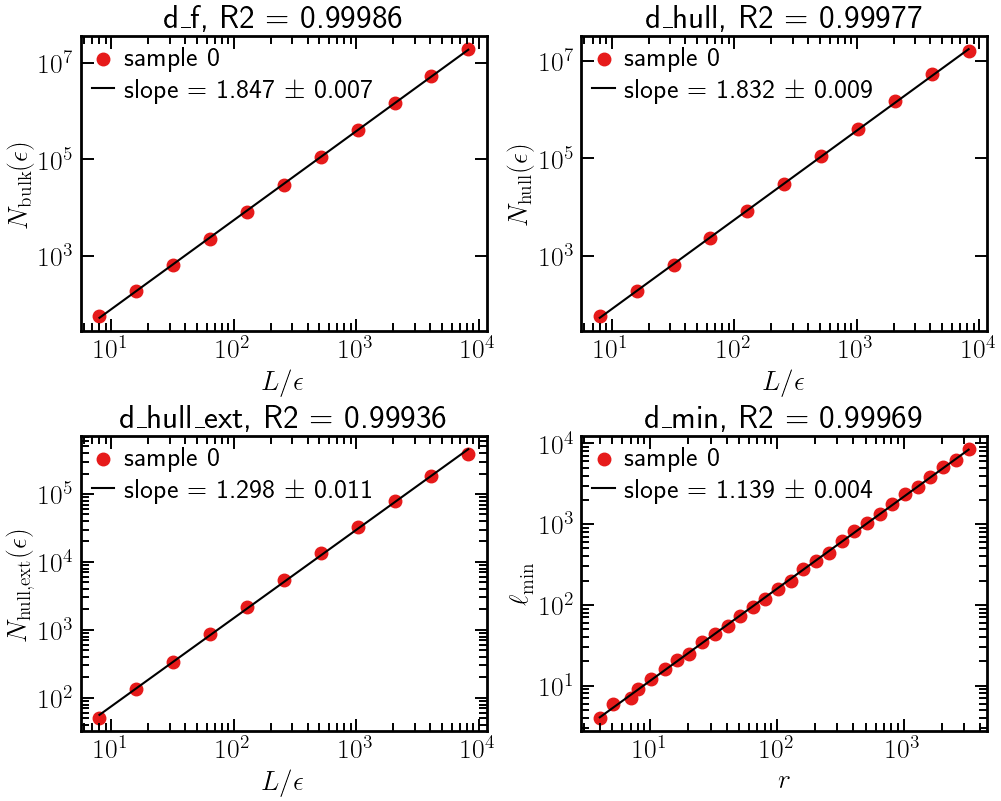

In [37]:
sample_index = 0

fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, observable in zip(axes.ravel(), OBSERVABLES):
    _, fit = plot_sample(payload, observable, sample_index=sample_index, ax=ax)
    slope_text = rounded_value_error(fit["slope"], fit["slope_err"])
    ax.set_title(f"{observable}, R2 = {fit['r2']:.5f}")

plt.show()


## Ajustes Por Amostra

In [38]:
fits = fit_all_observables(payload)
fits.head()

,type_percolation,num_colors,dim,L,f_T,c,rho,gap_over_L,P0,p0,...,seed,x_name,y_name,ignore_truncated,slope,slope_err,intercept,intercept_err,r2,n_points
0,bond,1,2,16384,0.068737,0.01,1.0,1.5,0.2,0.8,...,1084946650,L_over_epsilon,N_bulk,False,1.846759,0.007334,0.104267,0.043728,0.999858,11
1,bond,1,2,16384,0.068737,0.01,1.0,1.5,0.2,0.8,...,1126131724,L_over_epsilon,N_bulk,False,1.856873,0.004168,0.164306,0.024852,0.999955,11
2,bond,1,2,16384,0.068737,0.01,1.0,1.5,0.2,0.8,...,1126131724,L_over_epsilon,N_bulk,False,1.873834,0.002628,0.174737,0.015669,0.999982,11
3,bond,1,2,16384,0.068737,0.01,1.0,1.5,0.2,0.8,...,1126131724,L_over_epsilon,N_bulk,False,1.886594,0.003032,0.252472,0.018078,0.999977,11
4,bond,1,2,16384,0.068737,0.01,1.0,1.5,0.2,0.8,...,1126131724,L_over_epsilon,N_bulk,False,1.864559,0.006084,0.128870,0.036276,0.999904,11


## Diagnostico Do d_min


In [39]:
dmin_default = fit_samples(payload, "d_min")
dmin_mean = fit_samples(payload, "d_min", y_variant="ell_mean")

pd.concat([
    summarize_fits(dmin_default).assign(estimator="default_ell_min_todos_bins"),
    summarize_fits(dmin_mean).assign(estimator="ell_mean_todos_bins"),
], ignore_index=True)[["estimator", "observable", "slope_mean", "slope_std", "slope_sem", "r2_mean", "n_samples"]]


,estimator,observable,slope_mean,slope_std,slope_sem,r2_mean,n_samples
0,default_ell_min_todos_bins,d_min,1.141095,0.006137,0.000723,0.999597,72
1,ell_mean_todos_bins,d_min,1.141095,0.006137,0.000723,0.999597,72


In [40]:
summary = summarize_fits(fits)
summary

,observable,slope_mean,slope_std,slope_sem,r2_mean,n_samples
0,d_f,1.863396,0.015003,0.001768,0.999916,72
1,d_hull,1.849085,0.014978,0.001765,0.999773,72
2,d_hull_ext,1.297708,0.009782,0.001153,0.999352,72
3,d_min,1.141095,0.006137,0.000723,0.999597,72
4,d_min_yardstick,1.125820,0.007568,0.000892,0.999883,72


## Controle Da Janela De Ajuste

In [41]:
fit_window = {
    "x_min": None,
    "x_max": None,
}


In [42]:
fits_window = fit_all_observables(payload, **fit_window)
summarize_fits(fits_window)


,observable,slope_mean,slope_std,slope_sem,r2_mean,n_samples
0,d_f,1.863396,0.015003,0.001768,0.999916,72
1,d_hull,1.849085,0.014978,0.001765,0.999773,72
2,d_hull_ext,1.297708,0.009782,0.001153,0.999352,72
3,d_min,1.141095,0.006137,0.000723,0.999597,72
4,d_min_yardstick,1.125820,0.007568,0.000892,0.999883,72


## Plot Das Medias Das Series

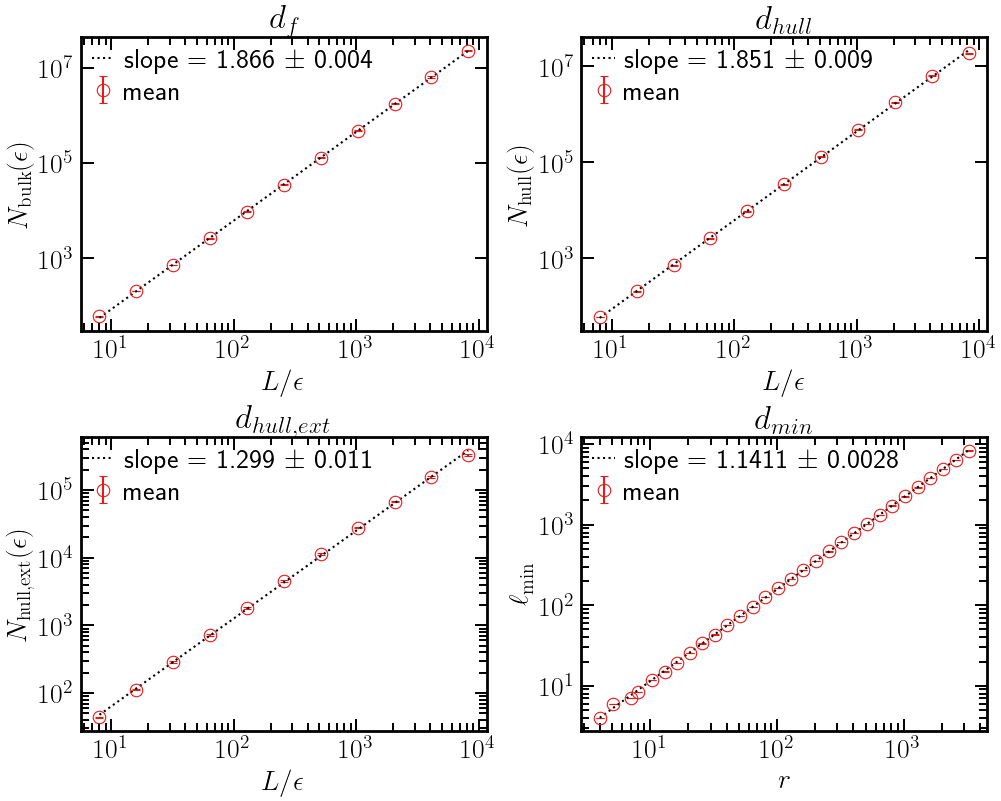

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
for ax, observable in zip(axes.ravel(), OBSERVABLES):
    title = f"$d_{{{observable[2:6]},ext}}$"

    if(observable!="d_hull_ext"):
        title = f"$d_{{{observable[2:]}}}$"

    _, fit = plot_mean(payload, observable, ax=ax, **fit_window)
    slope_text = rounded_value_error(fit["slope"], fit["slope_err"])
    #print(f"$d_{{{observable[2:]}}}$")
    ax.set_title(title)
#plt.savefig(f"../results/1Color/2D/props_fmin_bond.pdf")
plt.show()


## Ajustes Em Todos Os Arquivos

In [44]:
all_fits = []
for path in df_index["path"]:
    data = read_counts_file(path)
    all_fits.append(fit_all_observables(data, **fit_window))

all_fits = pd.concat(all_fits, ignore_index=True)
all_fits.head()

,type_percolation,num_colors,dim,L,f_T,c,rho,gap_over_L,P0,p0,...,seed,x_name,y_name,ignore_truncated,slope,slope_err,intercept,intercept_err,r2,n_points
0,bond,1,2,16384,0.068737,0.01,1.0,1.5,0.2,0.8,...,1084946650,L_over_epsilon,N_bulk,False,1.846759,0.007334,0.104267,0.043728,0.999858,11
1,bond,1,2,16384,0.068737,0.01,1.0,1.5,0.2,0.8,...,1126131724,L_over_epsilon,N_bulk,False,1.856873,0.004168,0.164306,0.024852,0.999955,11
2,bond,1,2,16384,0.068737,0.01,1.0,1.5,0.2,0.8,...,1126131724,L_over_epsilon,N_bulk,False,1.873834,0.002628,0.174737,0.015669,0.999982,11
3,bond,1,2,16384,0.068737,0.01,1.0,1.5,0.2,0.8,...,1126131724,L_over_epsilon,N_bulk,False,1.886594,0.003032,0.252472,0.018078,0.999977,11
4,bond,1,2,16384,0.068737,0.01,1.0,1.5,0.2,0.8,...,1126131724,L_over_epsilon,N_bulk,False,1.864559,0.006084,0.128870,0.036276,0.999904,11


In [45]:
all_summary = (
    all_fits
    .groupby(["type_percolation", "dim", "L", "f_T", "c", "rho", "P0", "p0", "observable"], as_index=False)
    .agg(
        slope_mean=("slope", "mean"),
        slope_std=("slope", "std"),
        slope_sem=("slope", lambda x: x.std() / np.sqrt(x.notna().sum())),
        r2_mean=("r2", "mean"),
        n_samples=("slope", "count"),
    )
)

all_summary

,type_percolation,dim,L,f_T,c,rho,P0,p0,observable,slope_mean,slope_std,slope_sem,r2_mean,n_samples
0,bond,2,16384,0.068737,0.01,1.0,0.2,0.8,d_f,1.863396,0.015003,0.001768,0.999916,72
1,bond,2,16384,0.068737,0.01,1.0,0.2,0.8,d_hull,1.849085,0.014978,0.001765,0.999773,72
2,bond,2,16384,0.068737,0.01,1.0,0.2,0.8,d_hull_ext,1.297708,0.009782,0.001153,0.999352,72
3,bond,2,16384,0.068737,0.01,1.0,0.2,0.8,d_min,1.141095,0.006137,0.000723,0.999597,72
4,bond,2,16384,0.068737,0.01,1.0,0.2,0.8,d_min_yardstick,1.125820,0.007568,0.000892,0.999883,72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,node,2,16384,0.087071,0.01,1.0,0.2,0.8,d_f,1.883193,0.008355,0.000836,0.999926,100
91,node,2,16384,0.087071,0.01,1.0,0.2,0.8,d_hull,1.883040,0.008355,0.000835,0.999924,100
92,node,2,16384,0.087071,0.01,1.0,0.2,0.8,d_hull_ext,1.319771,0.010073,0.001007,0.999833,100
93,node,2,16384,0.087071,0.01,1.0,0.2,0.8,d_min,1.116238,0.004598,0.000460,0.999577,100


$d_{f}$
0     1.00
5     1.05
10    1.50
15    2.00
20    3.00
Name: f_T, dtype: float64
$d_{min}$
3     1.00
8     1.05
13    1.50
18    2.00
23    3.00
Name: f_T, dtype: float64
$d_{hull}$
1     1.00
6     1.05
11    1.50
16    2.00
21    3.00
Name: f_T, dtype: float64
$d_{hull_ext}$
2     1.00
7     1.05
12    1.50
17    2.00
22    3.00
Name: f_T, dtype: float64


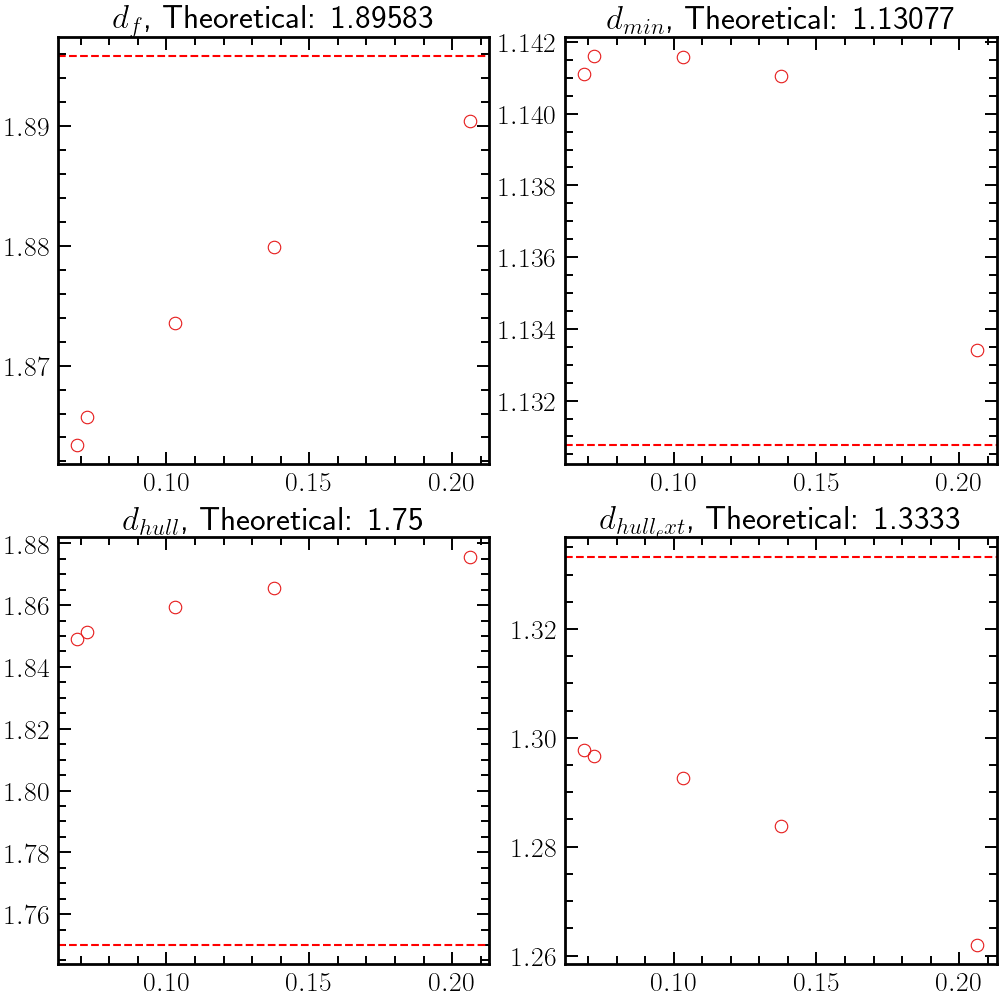

In [62]:
props = ['d_f', 'd_min', 'd_hull', 'd_hull_ext']
theorical_values = [1.89583, 1.13077, 1.75, 1.3333]
base = 5
n_rows = 2
n_columns = 2

fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*base, n_rows*base), constrained_layout=True)
for ax, observable, theorical_value in zip(axes.ravel(), props, theorical_values):
    prop = f"$d_{{{observable[2:]}}}$"
    print(prop)
    df_sub = all_summary[(all_summary['observable']==observable) & (all_summary['type_percolation']=='bond')]
    d_f = df_sub['slope_mean']
    f_T = df_sub['f_T']
    print(f_T/f_T.values[0])
    ax.plot(f_T, d_f,'o')
    ax.axhline(y=theorical_value, color='r', linestyle='--')
    ax.set_title(f"{prop}, Theoretical: {theorical_value}")

#plt.axhline(y=df_theorical)
plt.show()